In [28]:
import numpy as np
import numpy.linalg as LA
import scipy
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from tqdm import tqdm
import scipy.stats as stats
import scipy.optimize as opt
from typing import Sequence, List, Callable, Tuple, Optional
import cvxpy as cp

# Construction of the matrix

In [29]:
def generate_matrix(n,mu,L):
  Lamb = np.zeros([n,n])
  for i in range(n):
    Lamb[i,i] = np.random.uniform(mu,L)
  B1 = np.random.rand(n,n)
  Q1, R1 = np.linalg.qr(B1)
  matrix_gen = np.matmul(np.matmul(Q1,Lamb),np.transpose(Q1))
  return matrix_gen

# Construction of the objective and the constraints

In [30]:
# Construction of the objectives
dim_x = 10

mu_obj = 0
L_obj = 10

L = L_obj
mu = mu_obj

A = generate_matrix(dim_x,mu_obj,L_obj)
b = np.random.randn(dim_x)

x_opt = - LA.inv(A+np.transpose(A)) @ b


# Construction of the constraints
# Change this number if required
no_constraints = 1000

mu_con = 0
L_con = 2

C_i = np.zeros([dim_x,dim_x,no_constraints])
u_i = np.zeros([dim_x,no_constraints])
e_i = np.zeros([no_constraints])

for i in tqdm(range(no_constraints)):
  C_i[:,:,i] = generate_matrix(dim_x, mu_con, L_con)
  u_i[:,i] = np.random.randn(dim_x)                 ## randn generates normal distribution between [0,1]
  e_i[i] = np.random.uniform(1,2)


# Construction of Y constraints
l_val = -10.0
u_val = 10.0


100%|████████████████████████████████████| 1000/1000 [00:00<00:00, 18801.20it/s]


# Optimal Function value for unconstrained case

In [31]:
f_opt = x_opt @ A @ x_opt + b @ x_opt
print(f_opt)

-0.7002237436390008


# CVXPY Implementation

In [32]:
# variable
x = cp.Variable(dim_x)

# Objective
objective = cp.Minimize(cp.quad_form(x, A) + b @ x)

# Constraints
constraints = [x >= l_val, x <= u_val]
for i in range(no_constraints):
    constraint_expr = cp.quad_form(x, C_i[:,:,i]) + u_i[:,i] @ x - e_i[i]
    constraints.append(constraint_expr <= 0)

# Problem and solve
prob = cp.Problem(objective, constraints)

# Try solving with ECOS, if it fails, try SCS
try:
    prob.solve(solver=cp.ECOS, verbose=True)
except cp.SolverError as e:
    print(f"ECOS solver failed: {e}")
    print("Trying SCS solver instead...")
    prob.solve(solver=cp.SCS, verbose=True)  # Fallback to SCS solver


# Output
print("Optimal value:", prob.value)
print("Optimal x:", x.value)

                                     CVXPY                                     
                                     v1.5.3                                    
(CVXPY) May 28 03:19:20 AM: Your problem has 10 variables, 1020 constraints, and 0 parameters.
(CVXPY) May 28 03:19:20 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 28 03:19:20 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 28 03:19:20 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 28 03:19:20 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) May 28 03:19:20 AM: Compiling problem (target solver=ECOS).
(

# IPOPT Implementation

In [22]:
# pip install casadi

In [23]:
# import casadi as ca

# # Assume these are already defined:
# # dim_x, A, b, l_val, u_val, no_constraints, C_i, u_i, e_i

# # Convert inputs to CasADi types
# A = ca.DM(A)
# b = ca.DM(b).reshape((dim_x, 1))

# # If l_val/u_val are scalars, broadcast them to vectors
# if np.isscalar(l_val):
#     lbx = [float(l_val)] * dim_x
# else:
#     lbx = np.array(l_val).flatten().tolist()

# if np.isscalar(u_val):
#     ubx = [float(u_val)] * dim_x
# else:
#     ubx = np.array(u_val).flatten().tolist()

# # Decision variable
# x = ca.MX.sym('x', dim_x, 1)

# # Objective: x^T A x + b^T x
# obj = ca.mtimes([x.T, A, x]) + ca.mtimes(b.T, x)

# # Constraints
# g_list = []

# # Box constraints handled through lbx/ubx, so no need to add them to g_list

# for i in range(no_constraints):
#     Ci = ca.DM(C_i[:, :, i])
#     ui = ca.DM(u_i[:, i]).reshape((dim_x, 1))
#     expr = ca.mtimes([x.T, Ci, x]) + ca.mtimes(ui.T, x) - float(e_i[i])
#     g_list.append(expr)

# # Stack constraints into one vector
# g = ca.vertcat(*g_list) if len(g_list) > 0 else ca.vertcat()

# # NLP definition
# nlp = {
#     'x': x,
#     'f': obj,
#     'g': g
# }

# # Solver
# opts = {
#     'ipopt.print_level': 5,
#     'print_time': False,
#     'ipopt.tol': 1e-8
# }

# solver = ca.nlpsol('solver', 'ipopt', nlp, opts)

# # Constraint bounds: all quadratic constraints are <= 0
# lbg = [-ca.inf] * no_constraints
# ubg = [0.0] * no_constraints

# # Initial guess
# x0 = np.zeros(dim_x)

# # Solve
# sol = solver(
#     x0=x0,
#     lbx=lbx,
#     ubx=ubx,
#     lbg=lbg,
#     ubg=ubg
# )

# # Extract solution
# x_opt = np.array(sol['x']).flatten()
# opt_val = float(sol['f'])

# print("Optimal value:", opt_val)
# print("Optimal x:", x_opt)

# Some Auxiliary Function Definitions

In [6]:
def g_val(i, z):
    raw = z @ C_i[:,:,i] @ z + u_i[:,i] @ z - e_i[i]
    return raw

def g_plus(i, z):
    return max(0.0, g_val(i, z))

def subgradient(i, z):  # Computes gradient / subgradient of the constraints
    #raw2 = C_i[:,:,i] @ z + u_i[:,i]
    # if raw>0, subgradient is a_i; else it's 0
    return ((C_i[:,:,i] + np.transpose(C_i[:,:,i])) @ z + u_i[:,i])

def project_Y(z):
    # project onto the box [lval,u_val]^dim_x
    return np.clip(z, l_val, u_val)

def grad_f(x):  # Computes gradient / subgradient of the objective function
    return (A + np.transpose(A)) @ x + b

def compute_function_values(x_k_bar_list, A, b):
    """
    Compute function values f(x) = x^T A x + b^T x
    for each x in x_k_bar_list.

    Args:
        x_k_bar_list : list of np.ndarray, each vector x_k_bar
        A            : np.ndarray, matrix in the quadratic term
        b            : np.ndarray, vector in the linear term

    Returns:
        list of floats : [f(x_1), f(x_2), ..., f(x_T)]
    """
    func_values = []
    for x in x_k_bar_list:
        f_x = float(x @ A @ x + b @ x)
        func_values.append(f_x)
    return func_values


def weighted_running_average(hist_list, gamma):
    """
    avg_itr_list[k] = (sum_{t=0}^k gamma[t] * hist_list[t]) / (sum_{t=0}^k gamma[t])
    """
    n_steps = len(hist_list)
    if n_steps == 0:
        return []

    num = np.zeros_like(np.asarray(hist_list[0], dtype=float))
    den = 0.0
    avg_itr_list = []

    for i in range(n_steps):
        x = np.asarray(hist_list[i], dtype=float)
        w = float(gamma[i])
        num += w * x
        den += w
        avg_itr_list.append(num / den)

    return avg_itr_list


def compute_infeas_gap_list(x_hat_list, g_plus, num_const):
    """
    For each iterate 'itr' in x_hat_list, compute the infeasibility gap:
        gap(itr) = sum_{i=0}^{num_const-1} g_plus(i, itr)

    Assumes g_plus(i, z) returns max{g_i(z), 0}. Returns a Python list.
    """
    gaps = []
    for itr in x_hat_list:
        total = 0.0
        for i in range(num_const):
            val = g_plus(i, itr)
            if val > 0.0:            # defensive; g_plus should already be ≥ 0
                total += float(val)
        gaps.append(total)
    return gaps

# Experiment Details

In [7]:
# Number of experiments for randomized feasibility

no_of_experiments = 5

# Number of iterations
Tot_itr = 1000

# Initial point
x0 = np.random.uniform(l_val, u_val, dim_x)

# Randomized Feasibility Algorithm

In [8]:
def randomized_feasibility(v_k: np.ndarray,
                           N_k: int,
                           beta: float,
                           m: int,
                           g_plus,
                           subgradient,
                           project_Y) -> np.ndarray:
    """
    Implements Algorithm 1 (Randomized Feasibility).

    Args:
      v_k          : np.ndarray, initial point z_k^0 in R^n
      N_k          : int, number of inner iterations
      beta         : float, deterministic stepsize (0 < beta < 2)
      m            : int, number of constraints (indices 0..m-1)
      g_plus       : callable(i, z) -> g_i^+(z)
      subgradient  : callable(i, z) -> d ∈ ∂ g_i^+(z)
      project_Y    : callable(z) -> projection of z onto Y

    Returns:
      x_k = z_k^{N_k}: the final iterate after N_k steps.
    """
    # initialize
    z = v_k.copy()

    for _ in range(N_k):
        # 1) pick one constraint index at random
        i = np.random.randint(0, m)

        # 2) evaluate the positive part g_i^+(z)
        g_val = g_plus(i, z)

        # 3) get a stochastic subgradient d ∈ ∂ g_i^+(z)
        d = subgradient(i, z)

        # 4) do the step, guarding against zero subgradient
        norm_d2 = np.dot(d, d)
        if norm_d2 > 0:
            z = z - beta * (g_val / norm_d2) * d

        # 5) project back into Y
        z = project_Y(z)

    return z


# Gardient Descent Algorithm

In [9]:
# make_bar_alpha is used to compute $\bar \alpha$ required in the averaging of x_itr

def make_bar_alpha(L: float, mu: float, epsilon: float, M_f: float) -> float:
    """Compute \bar alpha from theorem."""
    return min(1.0 / (2.0 * (L - mu)), 1.0 / L, epsilon / (2.0 * (M_f**2)))


# Function to compute the average of the iterates for strongly convex case

def compute_bar_x_running(
    x_itr: Sequence[np.ndarray],
    alpha_list: Sequence[float],
    bar_alpha: float,
    mu: float
) -> List[np.ndarray]:
    """
    Compute running averaged points bar_x_{k-1} for k=1..K where K = len(x_itr).

    The theorem's average for a fixed k is
      bar_x_{k-1} = sum_{t=1}^{k} (1 - bar_alpha * mu)^{k-t} * alpha_{t} * x_{t}
                    ---------------------------------------------------------------
                    sum_{t=1}^{k} alpha_{t} * (1 - bar_alpha * mu)^{k-t}

    This function produces bar_x_{k} for each k = 1..K (K = len(x_itr)),
    and returns them as a list of length K:
      [bar_x_{0}, bar_x_{1}, ..., bar_x_{K-1}]

    Args:
        x_itr     : sequence of np.ndarray, x_1 .. x_K
        alpha_list: sequence of floats, must contain alpha_0 .. alpha_K (length >= K+1)
        bar_alpha : scalar \bar\alpha from the theorem
        mu        : strong-convexity parameter μ

    Returns:
        List[np.ndarray] of length K where entry j is bar_x_{j} (i.e. \bar x_{j})
    """
    K = len(x_itr)
    if K == 0:
        return []

    # Now require alpha_list to have at least K entries (alpha_1 .. alpha_K)
    if len(alpha_list) < K:
        raise ValueError(f"alpha_list must contain at least alpha_1..alpha_{K} (len >= {K}).")

    factor = 1.0 - bar_alpha * mu
    x_array = np.stack(x_itr, axis=0)  # rows correspond to x_1..x_K

    bar_x_list: List[np.ndarray] = []

    # for k = 1..K compute bar_x_{k-1}
    for k in range(1, K + 1):
        # exponents: [k-1, k-2, ..., 0] corresponding to powers (1 - bar_alpha*mu)^{k-j}
        exponents = np.arange(k - 1, -1, -1, dtype=float)

        # alpha slice: alpha_1..alpha_k are stored in alpha_list[0:k]
        alphas = np.array(alpha_list[:k], dtype=float)  # length k

        weights = alphas * (factor ** exponents)  # length k
        denom = weights.sum()
        if denom == 0.0:
            bar_x = x_array[k - 1].copy()  # fallback to last iterate x_k
        else:
            # weighted average over x_1..x_k
            bar_x = np.tensordot(weights, x_array[:k], axes=1) / denom
        bar_x_list.append(bar_x)

    return bar_x_list

In [10]:
def gradient_descent_with_randomized_feasibility(
    x0: np.ndarray,
    grad_f,                  # callable: ∇f(x)
    alpha_schedule,          # callable: α_k step size at iteration k
    N_schedule,              # callable: N_k samples for Algorithm 1 at iteration k
    project_Y,               # projection onto feasible set Y
    g_plus,
    subgradient,
    T: int                   # total iterations
) -> np.ndarray:
    """
    Implements Algorithm 2: Gradient Descent with Randomized Feasibility

    Args:
        x0           : np.ndarray, initial point in R^n
        grad_f       : callable(x) → ∇f(x)
        alpha_schedule: callable(k) → step size α_k
        N_schedule   : callable(k) → number of samples N_k for inner loop
        project_Y    : projection function for constraint set Y
        g_plus       : callable(i, z) → g_i^+(z)
        subgradient  : callable(i, z) → subgradient of g_i^+(z)
        T            : total number of outer iterations

    Returns:
        x_T : the final iterate after T steps
    """
    x_k = x0.copy()

    v_itr = []
    x_itr = []
    func_x_k = []
    alpha_used_list = []
    grad_norm_list = []

    for k in tqdm(range(T)):
        # Step 1: gradient step and projection
        grad = grad_f(x_k)
        alpha_k = alpha_schedule(k, grad)
        grad_norm_list.append(LA.norm(grad))
        v_k = project_Y(x_k - alpha_k * grad)
        v_itr.append(v_k)
        alpha_used_list.append(alpha_k)

        # Step 2: run randomized feasibility to enforce constraints
        N_k = N_schedule(k)
        x_k = randomized_feasibility(
            v_k, N_k, beta=1.0, m=no_constraints,
            g_plus=g_plus,
            subgradient=subgradient,
            project_Y=project_Y
        )

        x_itr.append(x_k)

        func_x_k.append(x_k @ A @ x_k + b @ x_k)

    return v_itr, alpha_used_list, x_itr, func_x_k, grad_norm_list


# Run GD Algorithm with $\alpha_k = \min \left\{ \frac{1}{2(L-\mu)}, \frac{1}{L}, \tfrac{\epsilon}{2 \|\nabla f(x_k)\|^2} \right\}$

# and $N_k = \lceil \log(k) \rceil$

In [ ]:
# # Number of experiments

# #no_of_experiments = 1

# # Number of iterations
# #Tot_itr=10

# # Adaptive Step Size Schedule
# # requires epsilon for designing the schedule

# epsilon = 1
# def alpha_schedule_ada(k, grad):
#     """
#     Adaptive step-size:
#         α_k = min{ 1/(2(L−μ)), 1/L, ε / (2‖∇f(x_k)‖²) }
#     """
#     grad_norm_sq = LA.norm(grad)**2
#     alpha_k = min(1.0 / (2.0 * (L_obj - mu_obj)), 1.0 / L_obj, epsilon / (2.0 * grad_norm_sq))
#     return alpha_k


# # Sample schedule for randomized feasibility
# def N_schedule(k):
#     return int(np.ceil(np.log(k+1)))


# # containers to accumulate results across experiments
# func_adagd_log = []   # will hold lists/arrays: func_val_list for each experiment
# infeas_adagd_log = []      # will hold lists/arrays: infeas_x_k_bar for each experiment


# for i in range(no_of_experiments):
#   v_itr, alpha_used_list, x_itr, func_x_k, grad_norm_list = gradient_descent_with_randomized_feasibility(
#     x0=x0,
#     grad_f=grad_f,
#     alpha_schedule=alpha_schedule_ada,
#     N_schedule=N_schedule,
#     project_Y=project_Y,
#     g_plus=g_plus,
#     subgradient=subgradient,
#     T=Tot_itr
#     )

#   # Compute $\bar \alpha$ used in iterate averaging
#   M_f = np.max(grad_norm_list)
#   alpha_bar = make_bar_alpha(L, mu, epsilon, M_f)

#   # Compute averaged iterate list
#   x_k_bar_list = compute_bar_x_running(x_itr, alpha_used_list, alpha_bar, mu)

#   # Compute function values at the averaged iterates
#   func_val_list = compute_function_values(x_k_bar_list, A, b)

#   # Compute the infeasibility gap
#   infeas_x_k_bar = compute_infeas_gap_list(x_hat_list = x_k_bar_list, g_plus = g_plus, num_const = no_constraints)

#   # Store results for this experiment. Convert to numpy arrays and append
#   func_adagd_log.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
#   infeas_adagd_log.append(np.asarray(infeas_x_k_bar, dtype=float))

# Run GD Algorithm with $\alpha_k = \min \left\{ \frac{1}{2(L-\mu)}, \frac{1}{L}, \tfrac{\epsilon}{2 \|\nabla f(x_k)\|^2} \right\}$

# and $N_k = \lceil k^{1/2} \rceil$

In [ ]:
# # Number of experiments

# #no_of_experiments = 1

# # Number of iterations
# #Tot_itr=10

# # Adaptive Step Size Schedule
# # requires epsilon for designing the schedule

# epsilon = 1e6
# def alpha_schedule_ada(k, grad):
#     """
#     Adaptive step-size:
#         α_k = min{ 1/(2(L−μ)), 1/L, ε / (2‖∇f(x_k)‖²) }
#     """
#     grad_norm_sq = LA.norm(grad)**2
#     alpha_k = min(1.0 / (2.0 * (L_obj - mu_obj)), 1.0 / L_obj, epsilon / (2.0 * grad_norm_sq))
#     # if k <= Tot_itr/2:
#     #     alpha_k = min(1.0 / (2.0 * (L_obj - mu_obj)), 1.0 / L_obj, epsilon / (2.0 * grad_norm_sq))
#     # elif k > Tot_itr/2:
#     #     alpha_k = min(1.0 / (2.0 * (L_obj - mu_obj)), 1.0 / L_obj, epsilon / (1000.0*2.0 * grad_norm_sq))
#     return alpha_k


# # Sample schedule for randomized feasibility
# def N_schedule(k):
#     return int(np.ceil(np.sqrt(k+1)))


# # containers to accumulate results across experiments
# func_adagd_sqrt = []   # will hold lists/arrays: func_val_list for each experiment
# infeas_adagd_sqrt = []      # will hold lists/arrays: infeas_x_k_bar for each experiment


# for i in range(no_of_experiments):
#   v_itr, alpha_used_list, x_itr, func_x_k, grad_norm_list = gradient_descent_with_randomized_feasibility(
#     x0=x0,
#     grad_f=grad_f,
#     alpha_schedule=alpha_schedule_ada,
#     N_schedule=N_schedule,
#     project_Y=project_Y,
#     g_plus=g_plus,
#     subgradient=subgradient,
#     T=Tot_itr
#     )

#   # Compute $\bar \alpha$ used in iterate averaging
#   M_f = np.max(grad_norm_list)
#   alpha_bar = make_bar_alpha(L, mu, epsilon, M_f)

#   # Compute averaged iterate list
#   x_k_bar_list = compute_bar_x_running(x_itr, alpha_used_list, alpha_bar, mu)

#   # Compute function values at the averaged iterates
#   func_val_list = compute_function_values(x_k_bar_list, A, b)

#   # Compute the infeasibility gap
#   infeas_x_k_bar = compute_infeas_gap_list(x_hat_list = x_k_bar_list, g_plus = g_plus, num_const = no_constraints)

#   # Store results for this experiment. Convert to numpy arrays and append
#   func_adagd_sqrt.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
#   infeas_adagd_sqrt.append(np.asarray(infeas_x_k_bar, dtype=float))

# Run GD Algorithm with $\alpha_k = \frac{4}{\mu(k+1)}$ and $N_k = \lceil \log(k) \rceil$


https://link.springer.com/content/pdf/10.1007/s00245-019-09609-7.pdf

In [ ]:
# # Number of experiments

# #no_of_experiments = 1

# # Number of iterations
# #Tot_itr=10

# # Diminishing Step Size Schedule

# def alpha_schedule_dim(k, grad):
#     """
#     Diminishing step-size:
#         α_k = 4/(μ(k+1))
#     """
#     alpha_k = 4.0 / (mu_obj * (k+1))
#     return alpha_k


# # Sample schedule for randomized feasibility
# def N_schedule(k):
#     return int(np.ceil(np.log(k+1)))


# # containers to accumulate results across experiments
# func_dimgd_log = []   # will hold lists/arrays: func_val_list for each experiment
# infeas_dimgd_log = []      # will hold lists/arrays: infeas_x_k_bar for each experiment


# # Generate averaging weights from k = 0..Tot_itr-1
# avg_weights = np.array([(k + 1)**2 for k in tqdm(range(Tot_itr))], dtype=float)

# for i in range(no_of_experiments):
#   v_itr, alpha_used_list, x_itr, func_x_k, grad_norm_list = gradient_descent_with_randomized_feasibility(
#     x0=x0,
#     grad_f=grad_f,
#     alpha_schedule=alpha_schedule_dim,
#     N_schedule=N_schedule,
#     project_Y=project_Y,
#     g_plus=g_plus,
#     subgradient=subgradient,
#     T=Tot_itr
#     )

#   # Compute averaged iterate list
#   x_k_bar_list = weighted_running_average(x_itr, avg_weights)

#   # Compute function values at the averaged iterates
#   func_val_list = compute_function_values(x_k_bar_list, A, b)

#   # Compute the infeasibility gap
#   infeas_x_k_bar = compute_infeas_gap_list(x_hat_list = x_k_bar_list, g_plus = g_plus, num_const = no_constraints)

#   # Store results for this experiment. Convert to numpy arrays and append
#   func_dimgd_log.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
#   infeas_dimgd_log.append(np.asarray(infeas_x_k_bar, dtype=float))

# Run GD Algorithm with $\alpha_k = \frac{4}{\mu(k+1)}$ and $N_k = \lceil k^{1/2} \rceil$


https://link.springer.com/content/pdf/10.1007/s00245-019-09609-7.pdf

In [ ]:
# # Number of experiments

# #no_of_experiments = 1

# # Number of iterations
# #Tot_itr=10

# # Diminishing Step Size Schedule

# def alpha_schedule_dim(k, grad):
#     """
#     Diminishing step-size:
#         α_k = 4/(μ(k+1))
#     """
#     alpha_k = 4.0 / (mu_obj * (k+1))
#     return alpha_k


# # Sample schedule for randomized feasibility
# def N_schedule(k):
#     return int(np.ceil(np.sqrt(k+1)))


# # containers to accumulate results across experiments
# func_dimgd_sqrt = []   # will hold lists/arrays: func_val_list for each experiment
# infeas_dimgd_sqrt = []      # will hold lists/arrays: infeas_x_k_bar for each experiment

# # Generate averaging weights from k = 0..Tot_itr-1
# avg_weights = np.array([(k + 1)**2 for k in tqdm(range(Tot_itr))], dtype=float)

# for i in range(no_of_experiments):
#   v_itr, alpha_used_list, x_itr, func_x_k, grad_norm_list = gradient_descent_with_randomized_feasibility(
#     x0=x0,
#     grad_f=grad_f,
#     alpha_schedule=alpha_schedule_dim,
#     N_schedule=N_schedule,
#     project_Y=project_Y,
#     g_plus=g_plus,
#     subgradient=subgradient,
#     T=Tot_itr
#     )

#   # Compute averaged iterate list
#   x_k_bar_list = weighted_running_average(x_itr, avg_weights)

#   # Compute function values at the averaged iterates
#   func_val_list = compute_function_values(x_k_bar_list, A, b)

#   # Compute the infeasibility gap
#   infeas_x_k_bar = compute_infeas_gap_list(x_hat_list = x_k_bar_list, g_plus = g_plus, num_const = no_constraints)

#   # Store results for this experiment. Convert to numpy arrays and append
#   func_dimgd_sqrt.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
#   infeas_dimgd_sqrt.append(np.asarray(infeas_x_k_bar, dtype=float))

# DOWS with Randomized Feasibility

In [9]:
def dows_with_randomized_feasibility(
    x0: np.ndarray,
    subgrad_f,              # callable: subgradient s_f(x)
    N_schedule,             # callable: N_k
    project_Y,              # projection onto feasible set Y
    g_plus,
    subgradient,
    T: int,
    r0: float               # initial radius estimate
):
    """
    Implements Algorithm 3: Distance over Weighted Subgradients (DoWS) with Randomized Feasibility.

    Args:
        x0          : np.ndarray, initial point in feasible set Y
        subgrad_f   : callable(x) → subgradient of f at x
        N_schedule  : callable(k) → number of samples N_k for inner loop
        project_Y   : projection function for constraint set Y
        g_plus      : callable(i, z) → g_i^+(z)
        subgradient : callable(i, z) → subgradient of g_i^+(z)
        T           : number of outer iterations
        r0          : initial radius estimate (positive float)

    Returns:
        x_k : final iterate after T steps
    """
    x_k = x0.copy()
    x_0 = x0.copy()
    r_prev = r0
    p_prev = 0.0

    func_bar_x_k = []
    bar_x_k_list = []

    # accumulator for weighted mean: initialize as zero vector
    num = np.zeros_like(x0, dtype=float)   # numerator accumulator (vector)
    den = 0.0

    for k in tqdm(range(T)):
        # Compute radius and subgradient
        s_f_k = subgrad_f(x_k)
        r_k = max(np.linalg.norm(x_k - x_0), r_prev)
        p_k = p_prev + r_k**2 * np.linalg.norm(s_f_k)**2

        # Compute step size
        alpha_k = r_k**2 / np.sqrt(p_k)
        #if (k+1) % 100 == 0:
        #    print(alpha_k)

        # Gradient step and projection
        v_k = project_Y(x_k - alpha_k * s_f_k)

        # Inner feasibility step (Algorithm 1)
        N_k = N_schedule(k)
        x_k = randomized_feasibility(
            v_k, N_k, beta=1.0, m=no_constraints,
            g_plus=g_plus,
            subgradient=subgradient,
            project_Y=project_Y
        )

        num += r_k**2 * x_k
        den += r_k**2
        bar_x_k = num / den
        bar_x_k_list.append(bar_x_k.copy())

        func_bar_x_k.append(bar_x_k @ A @ bar_x_k + b @ bar_x_k)

        # Update state
        r_prev = r_k
        p_prev = p_k

    return bar_x_k_list, func_bar_x_k


# Run DoWS with $N_k = \lceil \log k \rceil$

In [ ]:
# # Initial diameter estimate r0
# init_dist_est = 14

# # Sample schedule for randomized feasibility
# def N_schedule(k):
#     return int(np.ceil(np.log(k+1)))


# # containers to accumulate results across experiments
# func_dows_log = []   # will hold lists/arrays: func_val_list for each experiment
# infeas_dows_log = []      # will hold lists/arrays: infeas_x_k_bar for each experiment

# for i in range(no_of_experiments):
#   x_k_bar_list, func_val_list = dows_with_randomized_feasibility(
#     x0=x0,
#     subgrad_f=grad_f,
#     N_schedule=N_schedule,
#     project_Y=project_Y,
#     g_plus=g_plus,
#     subgradient=subgradient,
#     T=Tot_itr,
#     r0=init_dist_est
#     )

#   # Compute the infeasibility gap
#   infeas_x_k_bar = compute_infeas_gap_list(x_hat_list = x_k_bar_list, g_plus = g_plus, num_const = no_constraints)

#   # Store results for this experiment. Convert to numpy arrays and append
#   func_dows_log.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
#   infeas_dows_log.append(np.asarray(infeas_x_k_bar, dtype=float))


# Run DoWS with $N_k = \lceil k^{1/2} \rceil$

In [ ]:
# Initial diameter estimate r0
#init_dist_est = 14
init_dist_est = 1e-1

# Sample schedule for randomized feasibility
def N_schedule(k):
    return int(np.ceil(np.sqrt(k+1)))
    #return int(np.ceil(np.log(k+1)))


# containers to accumulate results across experiments
func_dows_sqrt = []   # will hold lists/arrays: func_val_list for each experiment
infeas_dows_sqrt = []      # will hold lists/arrays: infeas_x_k_bar for each experiment

for i in range(no_of_experiments):
  x_k_bar_list, func_val_list = dows_with_randomized_feasibility(
    x0=x0,
    subgrad_f=grad_f,
    N_schedule=N_schedule,
    project_Y=project_Y,
    g_plus=g_plus,
    subgradient=subgradient,
    T=Tot_itr,
    r0=init_dist_est
    )

  # Compute the infeasibility gap
  infeas_x_k_bar = compute_infeas_gap_list(x_hat_list = x_k_bar_list, g_plus = g_plus, num_const = no_constraints)

  # Store results for this experiment. Convert to numpy arrays and append
  func_dows_sqrt.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
  infeas_dows_sqrt.append(np.asarray(infeas_x_k_bar, dtype=float))


# T-DOWS Implementation

In [ ]:
def tdows_with_randomized_feasibility(
    x0: np.ndarray,
    subgrad_f,              # callable: subgradient s_f(x)
    N_schedule,             # callable: N_k
    project_Y,              # projection onto feasible set Y
    g_plus,
    subgradient,
    T: int,
    r0: float               # initial radius estimate
):
    """
    Implements Algorithm 3: Distance over Weighted Subgradients (DoWS) with Randomized Feasibility.

    Args:
        x0          : np.ndarray, initial point in feasible set Y
        subgrad_f   : callable(x) → subgradient of f at x
        N_schedule  : callable(k) → number of samples N_k for inner loop
        project_Y   : projection function for constraint set Y
        g_plus      : callable(i, z) → g_i^+(z)
        subgradient : callable(i, z) → subgradient of g_i^+(z)
        T           : number of outer iterations
        r0          : initial radius estimate (positive float)

    Returns:
        x_k : final iterate after T steps
    """
    x_k = x0.copy()
    x_0 = x0.copy()
    r_prev = r0
    p_prev = 0.0

    func_bar_x_k = []
    bar_x_k_list = []

    # accumulator for weighted mean: initialize as zero vector
    num = np.zeros_like(x0, dtype=float)   # numerator accumulator (vector)
    den = 0.0

    for k in tqdm(range(T)):
        # Compute radius and subgradient
        s_f_k = subgrad_f(x_k)
        r_k = max(np.linalg.norm(x_k - x_0), r_prev)
        p_k = p_prev + r_k**2 * np.linalg.norm(s_f_k)**2

        # Compute step size
        if k == 0:
            p_1 = p_k

        alpha_k = r_k**2 / (np.sqrt(2*p_k)*np.log((np.e)*p_k/p_1))

        #if (k+1) % 100 == 0:
        #    print(alpha_k)

        # Gradient step and projection
        v_k = project_Y(x_k - alpha_k * s_f_k)

        # Inner feasibility step (Algorithm 1)
        N_k = N_schedule(k)
        x_k = randomized_feasibility(
            v_k, N_k, beta=1.0, m=no_constraints,
            g_plus=g_plus,
            subgradient=subgradient,
            project_Y=project_Y
        )

        num += r_k**2 * x_k
        den += r_k**2
        bar_x_k = num / den
        bar_x_k_list.append(bar_x_k.copy())

        func_bar_x_k.append(bar_x_k @ A @ bar_x_k + b @ bar_x_k)

        # Update state
        r_prev = r_k
        p_prev = p_k

    return bar_x_k_list, func_bar_x_k


# Run T-DOWS with $N_k = \lceil \log k \rceil$

In [ ]:
# # Initial diameter estimate r0
# init_dist_est = 1

# # Sample schedule for randomized feasibility
# def N_schedule(k):
#     return int(np.ceil(np.log(k+1)))


# # containers to accumulate results across experiments
# func_tdows_log = []   # will hold lists/arrays: func_val_list for each experiment
# infeas_tdows_log = []      # will hold lists/arrays: infeas_x_k_bar for each experiment

# for i in range(no_of_experiments):
#   x_k_bar_list, func_val_list = tdows_with_randomized_feasibility(
#     x0=x0,
#     subgrad_f=grad_f,
#     N_schedule=N_schedule,
#     project_Y=project_Y,
#     g_plus=g_plus,
#     subgradient=subgradient,
#     T=Tot_itr,
#     r0=init_dist_est
#     )

#   # Compute the infeasibility gap
#   infeas_x_k_bar = compute_infeas_gap_list(x_hat_list = x_k_bar_list, g_plus = g_plus, num_const = no_constraints)

#   # Store results for this experiment. Convert to numpy arrays and append
#   func_tdows_log.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
#   infeas_tdows_log.append(np.asarray(infeas_x_k_bar, dtype=float))


# Run T-DOWS with $N_k = \lceil k^{1/2} \rceil$

In [ ]:
# Initial diameter estimate r0
init_dist_est = 1e-1

# Sample schedule for randomized feasibility
def N_schedule(k):
    return int(np.ceil(np.sqrt(k+1)))
    #return int(np.ceil(np.log(k+1)))


# containers to accumulate results across experiments
func_tdows_sqrt = []   # will hold lists/arrays: func_val_list for each experiment
infeas_tdows_sqrt = []      # will hold lists/arrays: infeas_x_k_bar for each experiment

for i in range(no_of_experiments):
  x_k_bar_list, func_val_list = tdows_with_randomized_feasibility(
    x0=x0,
    subgrad_f=grad_f,
    N_schedule=N_schedule,
    project_Y=project_Y,
    g_plus=g_plus,
    subgradient=subgradient,
    T=Tot_itr,
    r0=init_dist_est
    )

  # Compute the infeasibility gap
  infeas_x_k_bar = compute_infeas_gap_list(x_hat_list = x_k_bar_list, g_plus = g_plus, num_const = no_constraints)

  # Store results for this experiment. Convert to numpy arrays and append
  func_tdows_sqrt.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
  infeas_tdows_sqrt.append(np.asarray(infeas_x_k_bar, dtype=float))


# Arrow-Hurwicz Primal Dual Method

In [ ]:
def arrow_hurwicz(
    x0: np.ndarray,
    lam0: np.ndarray,
    grad_f,          # callable: ∇f(x)
    alpha_schedule,  # callable: α_k step size at iteration k
    tau_schedule,    # callable: τ_k step size at iteration k
    project_Y,       # projection onto feasible set Y
    g_val,           # callable(i, z) → g_i(z)
    subgradient,     # callable(i, z) → subgradient of g_i(z)
    T: int,          # total iterations
    m: int           # number of constraints (no_constraints)
):
    """
    Simplified Arrow–Hurwicz primal–dual algorithm.

    Args:
        x0          : np.ndarray, initial primal variable
        lam0        : np.ndarray, initial dual variables (size = number of constraints)
        grad_f      : callable(x) → gradient of objective f
        alpha_schedule : callable(k) → primal step size α_k
        project_Y   : callable(z) → projection onto feasible set Y
        g_val       : callable(i, z) → constraint function g_i(z)
        subgradient : callable(i, z) → subgradient of g_i(z)
        T           : total iterations
        m           : number of constraints (no_constraints)

    Returns:
        x_list, lam_list : lists of primal and dual iterates
    """

    x_k = x0.copy()
    lam_k = lam0.copy()

    x_list = []
    lam_list = []

    for k in tqdm(range(T)):
        alpha_k = alpha_schedule(k)
        #eta_k = 1.0 / np.sqrt(T)
        eta_k = tau_schedule(k) # dual step size = τ = 1/sqrt(T)

        # ---- Primal update ----
        grad_x = grad_f(x_k)
        for i in range(m):
            grad_x += lam_k[i] * subgradient(i, x_k)

        x_next = project_Y(x_k - alpha_k * grad_x)

        # ---- Dual update ----
        lam_next = np.zeros_like(lam_k)
        for i in range(m):
            lam_next[i] = max(0.0, lam_k[i] + eta_k * g_val(i, x_next))

        # ---- Store and update ----
        x_k = x_next
        lam_k = lam_next
        x_list.append(x_k.copy())
        lam_list.append(lam_k.copy())

    return x_list, lam_list


# Applying Arrow-Hurwicz based on the old paper step size rule

https://link.springer.com/content/pdf/10.1007/s10851-022-01089-9.pdf

In [ ]:
# --- simple schedules (example) ---
def alpha_schedule_const(k):
    return 1.0 / np.sqrt(Tot_itr)   # or whatever schedule you prefer

def tau_schedule_const(k):
    return 1.0 / np.sqrt(Tot_itr)  # or any schedule you want
    #return np.sqrt(k+1)

# --- call arrow_hurwicz ---
# Make sure x0, lam0, A, b, g_val, subgradient, no_constraints etc. are defined in the workspace.
x_list, lam_list = arrow_hurwicz(
    x0=x0,
    lam0=np.zeros(no_constraints),
    grad_f=grad_f,
    alpha_schedule=alpha_schedule_const,
    tau_schedule=tau_schedule_const,
    project_Y=project_Y,
    g_val=g_val,
    subgradient=subgradient,
    T=Tot_itr,
    m=no_constraints
)


avg_weights = np.ones(len(x_list), dtype=float)   # array of ones

# --- compute running (uniform) averages ---
# weighted_running_average computes avg_itr_list[k] = sum_{t=0}^k gamma[t]*hist[t] / sum_{t=0}^k gamma[t]
x_k_bar_list = weighted_running_average(hist_list=x_list, gamma=avg_weights)

# --- compute objective values at averaged iterates ---
func_vals_AH_old = np.abs(compute_function_values(x_k_bar_list, A, b) - prob.value)  # list of floats

# --- compute infeasibility at averaged iterates ---
infeas_x_k_bar_AH_old = compute_infeas_gap_list(x_hat_list=x_k_bar_list, g_plus=g_plus, num_const=no_constraints)



# Applying Arrow-Hurwicz based on the new paper step size rule. The algorithm is called Alt-GDA.

https://proceedings.mlr.press/v151/zhang22e/zhang22e.pdf (Theorem 4 and Corollary 3)

In [ ]:
# --- simple schedules (example) ---
def alpha_schedule_const(k):
    return 1 / (2* L_obj)   # or whatever schedule you prefer

def tau_schedule_const(k):
    return 1 / (2* L_obj)  # or any schedule you want
    #return np.sqrt(k+1)

# --- call arrow_hurwicz ---
# Make sure x0, lam0, A, b, g_val, subgradient, no_constraints etc. are defined in the workspace.
x_list, lam_list = arrow_hurwicz(
    x0=x0,
    lam0=np.zeros(no_constraints),
    grad_f=grad_f,
    alpha_schedule=alpha_schedule_const,
    tau_schedule=tau_schedule_const,
    project_Y=project_Y,
    g_val=g_val,
    subgradient=subgradient,
    T=Tot_itr,
    m=no_constraints
)


avg_weights = np.ones(len(x_list), dtype=float)   # array of ones

# --- compute running (uniform) averages ---
# weighted_running_average computes avg_itr_list[k] = sum_{t=0}^k gamma[t]*hist[t] / sum_{t=0}^k gamma[t]
x_k_bar_list = weighted_running_average(hist_list=x_list, gamma=avg_weights)

# --- compute objective values at averaged iterates ---
func_vals_Alt_GDA = np.abs(compute_function_values(x_k_bar_list, A, b) - prob.value) # list of floats

# --- compute infeasibility at averaged iterates ---
infeas_x_k_bar_Alt_GDA = compute_infeas_gap_list(x_hat_list=x_k_bar_list, g_plus=g_plus, num_const=no_constraints)



In [ ]:
func_vals_Alt_GDA[-1]

# Implementation of ADMM with log-barrier penalty functions

https://openreview.net/pdf?id=RQY2AXFMRiu

In [ ]:
def acvi(
    *,
    y0: np.ndarray,
    lam0: np.ndarray,
    g_val,             # callable: g_val(i, y) -> scalar
    mu_init: float,
    beta: float,
    delta: float,
    T: int,
    K: int,
    m: int,
    verbose: bool = False,
    barrier_tol: float = 1e-16
):
    """
    ACVI algorithm pseudocode:
      (I + (1/β)(A + A^T)) x = y - (1/β)(b + λ)
      y = argmin_y [ -μ Σ log(-g_i(y)) + (β/2)||y - (x + λ/β)||^2 ]
      λ = λ + β (x - y)
    """

    # initialization
    y_k_t = y0.copy().astype(float)
    lam_k_t = lam0.copy().astype(float)
    n = y_k_t.size

    A_sym = (A + A.T)
    I_n = np.eye(n)

    # storage
    y_hist, lam_hist = [], []
    x_last_per_t, x_mean_per_t = [], []

    mu_prev = mu_init

    for t in tqdm(range(T), desc="Outer loop"):
        mu_t = delta * mu_prev
        mu_prev = mu_t
        if verbose:
            print(f"[Outer {t}] mu_t={mu_t:.3e}")

        # accumulators for mean
        x_sum = np.zeros(n)

        for k in range(K):
            # ---- Step 1: x-update ----
            M = I_n + (1.0 / beta) * A_sym
            rhs = y_k_t - (1.0 / beta) * (b + lam_k_t)
            x_next = LA.solve(M, rhs)

            # accumulate for mean
            x_sum += x_next

            # ---- Step 2: y-update (barrier) ----
            def f_y(y, c, mu):
                g_main = np.array([g_val(i, y) for i in range(m)])

                g_up   = y - u_val                           # (n,)
                g_dn   = -y + l_val                          # (n,)
                g_vec  = np.concatenate([g_main, g_up, g_dn])

                if np.any(g_vec >= -barrier_tol):
                    return 1e12 + 1e6 * float(np.maximum(g_vec.max(), 0.0))
                return -mu * np.sum(np.log(-g_vec)) + (beta / 2.0) * np.sum((y - c) ** 2)

            center = x_next + lam_k_t / beta
            res = opt.minimize(lambda z: f_y(z, center, mu_t),
                               y_k_t, method="SLSQP", options={"maxiter": 300, "ftol": 1e-9})
            #if not res.success:
            #    print(f"[ACVI] barrier minimize failed at (t={t},k={k}): {res.message}")
            #    print("  max g_i(y) =", np.max([g_val(i, res.x) for i in range(m)]))

            y_next = res.x

            if not res.success and verbose:
                print(f"  [Inner {k}] barrier minimize failed: {res.message}")

            # ---- Step 3: λ-update ----
            lam_next = lam_k_t + beta * (x_next - y_next)

            # update for next inner iteration
            y_k_t = y_next.copy()
            lam_k_t = lam_next.copy()

        # ---- After inner loop ----
        x_last_per_t.append(x_next.copy())
        x_mean_per_t.append(x_sum / float(K))
        y_hist.append(y_k_t.copy())
        lam_hist.append(lam_k_t.copy())

    return x_last_per_t, x_mean_per_t, y_hist, lam_hist


In [ ]:
#Tot_itr = 1000

beta_ACVI = 1e-15 #0.08
mu_init = 10 #1e-5
delta = 0.5
K_inner = 5

x_last_per_t, x_mean_per_t, y_hist, lam_hist = acvi(
    y0=x0,
    lam0=np.zeros(len(x0)),
    g_val=g_val,             # callable: g_val(i, y) -> scalar
    mu_init=mu_init,
    beta=beta_ACVI,
    delta=delta,
    T=Tot_itr,
    K=K_inner,
    m=no_constraints,
    verbose=False,
    barrier_tol=0
)

# --- compute objective values at last iterate ---
func_vals_ACVI_last_itr = np.abs(compute_function_values(x_last_per_t, A, b) - prob.value) # list of floats

# --- compute infeasibility at last iterate ---
infeas_x_k_bar_ACVI_last_itr = compute_infeas_gap_list(x_hat_list=x_last_per_t, g_plus=g_plus, num_const=no_constraints)

# --- compute objective values at averaged iterate over inner loop ---
func_vals_ACVI_avg_itr = np.abs(compute_function_values(x_mean_per_t, A, b) - prob.value)  # list of floats

# --- compute infeasibility at averaged iterate over inner loop ---
infeas_x_k_bar_ACVI_avg_itr = compute_infeas_gap_list(x_hat_list=x_mean_per_t, g_plus=g_plus, num_const=no_constraints)

In [ ]:
func_vals_ACVI_avg_itr[-1]

In [ ]:
func_vals_ACVI_last_itr[-1]

In [ ]:
compute_function_values(x_mean_per_t, A, b)[-1]

In [ ]:
prob.value

In [ ]:
infeas_x_k_bar_ACVI_avg_itr[-1]

# Plotting the function values and the infeasibility gap

In [13]:
def compute_mean_std_across_experiments(func_logs, infeas_logs):
    """
    Stack results across experiments and compute mean and std along axis=0.

    Args:
        func_logs  : list of lists or arrays
                     func_logs[i] = list/array of function values from experiment i
        infeas_logs: list of lists or arrays
                     infeas_logs[i] = list/array of infeasibility values from experiment i

    Returns:
        mean_func, std_func, mean_infeas, std_infeas : np.ndarray
            mean_func   : mean of function values across experiments
            std_func    : standard deviation of function values across experiments
            mean_infeas : mean of infeasibility values across experiments
            std_infeas  : standard deviation of infeasibility values across experiments
    """
    # Find the minimum common length (in case experiments differ slightly)
    min_len = min(len(arr) for arr in func_logs)

    # Stack up to the min length
    func_stack = np.vstack([np.array(arr[:min_len]) for arr in func_logs])
    infeas_stack = np.vstack([np.array(arr[:min_len]) for arr in infeas_logs])

    # Compute statistics across experiments
    mean_func = np.mean(func_stack, axis=0)
    std_func  = np.std(func_stack, axis=0)
    mean_infeas = np.mean(infeas_stack, axis=0)
    std_infeas  = np.std(infeas_stack, axis=0)

    return mean_func, std_func, mean_infeas, std_infeas

In [14]:
# Generating the mean and standard deviations for plotting lists containing multiple experiments

# mean_func_adagd_log, std_func_adagd_log, mean_infeas_adagd_log, std_infeas_adagd_log = compute_mean_std_across_experiments(
#     func_adagd_log, infeas_adagd_log
#     )

# mean_func_adagd_sqrt, std_func_adagd_sqrt, mean_infeas_adagd_sqrt, std_infeas_adagd_sqrt = compute_mean_std_across_experiments(
#     func_adagd_sqrt, infeas_adagd_sqrt
#     )

# mean_func_dimgd_log, std_func_dimgd_log, mean_infeas_dimgd_log, std_infeas_dimgd_log = compute_mean_std_across_experiments(
#     func_dimgd_log, infeas_dimgd_log
#     )

# mean_func_dimgd_sqrt, std_func_dimgd_sqrt, mean_infeas_dimgd_sqrt, std_infeas_dimgd_sqrt = compute_mean_std_across_experiments(
#     func_dimgd_sqrt, infeas_dimgd_sqrt
#     )

# mean_func_dows_log, std_func_dows_log, mean_infeas_dows_log, std_infeas_dows_log = compute_mean_std_across_experiments(
#     func_dows_log, infeas_dows_log
#     )

mean_func_dows_sqrt, std_func_dows_sqrt, mean_infeas_dows_sqrt, std_infeas_dows_sqrt = compute_mean_std_across_experiments(
    func_dows_sqrt, infeas_dows_sqrt
    )

# mean_func_tdows_log, std_func_tdows_log, mean_infeas_tdows_log, std_infeas_tdows_log = compute_mean_std_across_experiments(
#     func_tdows_log, infeas_tdows_log
#     )

mean_func_tdows_sqrt, std_func_tdows_sqrt, mean_infeas_tdows_sqrt, std_infeas_tdows_sqrt = compute_mean_std_across_experiments(
    func_tdows_sqrt, infeas_tdows_sqrt
    )

NameError: name 'func_dows_sqrt' is not defined

# Function Value Plot

In [ ]:
iters = np.arange(1, Tot_itr + 1)

figure(1)
# ADA-GD
# plt.plot(iters, mean_func_adagd_log, color='blue', label='ADAGD-log')
# plt.fill_between(iters, mean_func_adagd_log - std_func_adagd_log,
#                  mean_func_adagd_log + std_func_adagd_log, color='blue', alpha=0.2)

# plt.plot(iters, mean_func_adagd_sqrt, color='#0072B2', label='Algorithm 2')
# plt.fill_between(iters, mean_func_adagd_sqrt - std_func_adagd_sqrt,
#                  mean_func_adagd_sqrt + std_func_adagd_sqrt, color='#0072B2', alpha=0.2)

# DOWS
# plt.plot(iters, mean_func_dows_log, color='green', label='DoWS-log')
# plt.fill_between(iters, mean_func_dows_log - std_func_dows_log,
#                  mean_func_dows_log + std_func_dows_log, color='green', alpha=0.2)

plt.plot(iters, mean_func_dows_sqrt, color='#009E73', label='Algorithm 3', marker = 'o', markevery = 150)
plt.fill_between(iters, mean_func_dows_sqrt - std_func_dows_sqrt,
                 mean_func_dows_sqrt + std_func_dows_sqrt, color='#009E73', alpha=0.2)

# T-DOWS
# plt.plot(iters, mean_func_tdows_log, color='purple', label='T-DoWS-log')
# plt.fill_between(iters, mean_func_tdows_log - std_func_tdows_log,
#                  mean_func_tdows_log + std_func_tdows_log, color='purple', alpha=0.2)

plt.plot(iters, mean_func_tdows_sqrt, color='#CC79A7', label='Algorithm 4')
plt.fill_between(iters, mean_func_tdows_sqrt - std_func_tdows_sqrt,
                 mean_func_tdows_sqrt + std_func_tdows_sqrt, color='#CC79A7', alpha=0.2)

# DIM-GD
# plt.plot(iters, mean_func_dimgd_log, color='orange', label='DIMGD-log')
# plt.fill_between(iters, mean_func_dimgd_log - std_func_dimgd_log,
#                  mean_func_dimgd_log + std_func_dimgd_log, color='orange', alpha=0.2)

# plt.plot(iters, mean_func_dimgd_sqrt, color='#D55E00', label=r'Algorithm 2 with $\alpha_k = \frac{4}{\mu(k+1)}$', marker = '*', markevery = 100)
# plt.fill_between(iters, mean_func_dimgd_sqrt - std_func_dimgd_sqrt,
#                  mean_func_dimgd_sqrt + std_func_dimgd_sqrt, color='#D55E00', alpha=0.2)


# Single-run baselines
plt.plot(iters, func_vals_AH_old, color='#56B4E9', linestyle='-', label='Arrow–Hurwicz', marker = '^', markevery = 100, alpha = 0.6)
plt.plot(iters, func_vals_Alt_GDA, color='#E69F00', linestyle='-', label='Alt-GDA', alpha = 0.6)
#plt.plot(iters, func_vals_ACVI_last_itr, color='darkcyan', linestyle='--', label='ACVI-last')
plt.plot(iters, func_vals_ACVI_avg_itr, color='magenta', linestyle='--', label='ACVI')

plt.xlabel('Number of iterations', fontsize=18)
plt.ylabel(r'$|f(\bar x_k) - f^*|$', fontsize=18)
#plt.title(r'$|f(\bar x_k) - f^*|$ ($f$ convex, $f^*$ unknown)', fontsize=18)
plt.yscale('log')
#plt.ylim(-0.4, -0.25)
plt.grid(True)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.show()

# Infeasibility Plot

In [ ]:
figure(2)
# ADA GD
# plt.plot(iters, mean_infeas_adagd_log, color='blue', label='ADAGD-log')
# plt.fill_between(iters, mean_infeas_adagd_log - std_infeas_adagd_log,
#                  mean_infeas_adagd_log + std_infeas_adagd_log, color='blue', alpha=0.2)

# plt.plot(iters, mean_infeas_adagd_sqrt, color='#0072B2', label='Algorithm 2')
# plt.fill_between(iters, mean_infeas_adagd_sqrt - std_infeas_adagd_sqrt,
#                  mean_infeas_adagd_sqrt + std_infeas_adagd_sqrt, color='#0072B2', alpha=0.2)

# DOWS
# plt.plot(iters, mean_infeas_dows_log, color='green', label='DoWS-log')
# plt.fill_between(iters, mean_infeas_dows_log - std_infeas_dows_log,
#                  mean_infeas_dows_log + std_infeas_dows_log, color='green', alpha=0.2)

plt.plot(iters, mean_infeas_dows_sqrt, color='#009E73', label='Algorithm 3')
plt.fill_between(iters, mean_infeas_dows_sqrt - std_infeas_dows_sqrt,
                 mean_infeas_dows_sqrt + std_infeas_dows_sqrt, color='#009E73', alpha=0.2)

# T-DOWS
# plt.plot(iters, mean_infeas_tdows_log, color='purple', label='T-DoWS-log')
# plt.fill_between(iters, mean_infeas_tdows_log - std_infeas_tdows_log,
#                  mean_infeas_tdows_log + std_infeas_tdows_log, color='purple', alpha=0.2)

plt.plot(iters, mean_infeas_tdows_sqrt, color='#CC79A7', label='Algorithm 4')
plt.fill_between(iters, mean_infeas_tdows_sqrt - std_infeas_tdows_sqrt,
                 mean_infeas_tdows_sqrt + std_infeas_tdows_sqrt, color='#CC79A7', alpha=0.2)

# DIM GD
# plt.plot(iters, mean_infeas_dimgd_log, color='orange', label='DIMGD-log')
# plt.fill_between(iters, mean_infeas_dimgd_log - std_infeas_dimgd_log,
#                  mean_infeas_dimgd_log + std_infeas_dimgd_log, color='orange', alpha=0.2)

# plt.plot(iters, mean_infeas_dimgd_sqrt, color='#D55E00', label=r'Algorithm 2 with $\alpha_k = \frac{4}{\mu(k+1)}$')
# plt.fill_between(iters, mean_infeas_dimgd_sqrt - std_infeas_dimgd_sqrt,
#                  mean_infeas_dimgd_sqrt + std_infeas_dimgd_sqrt, color='#D55E00', alpha=0.2)


# Single-run baselines (distinct colors)
plt.plot(iters, infeas_x_k_bar_AH_old, color='#56B4E9', linestyle='-', label='Arrow–Hurwicz', marker = '^', markevery = 5, alpha = 0.5)
plt.plot(iters, infeas_x_k_bar_Alt_GDA, color='#E69F00', linestyle='-', label='Alt-GDA', alpha = 0.4)
#plt.plot(iters, infeas_x_k_bar_ACVI_last_itr, color='darkcyan', linestyle='-', label='ACVI-last')
plt.plot(iters, infeas_x_k_bar_ACVI_avg_itr, color='magenta', linestyle='--', label='ACVI')

plt.xlabel('Number of iterations', fontsize=18)
plt.ylabel(r'Infeasibility $\sum_{i=1}^m g_i^+(\bar x_k)$', fontsize=18)
#plt.title('Infeasibility ($f$ convex, $f^*$ unknown)', fontsize=18)
plt.yscale('log')
plt.grid(True)
plt.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

# DoWS with Randomized Feasibility for different $N_k$. We choose $N_k = 20, 40, 50, 60, 80, 100, 500, 1000$.

In [60]:
# Initial radius estimate
init_dist_est = 1e-1

# Requested values of N_k
Nk_values = [10, 20, 40, 50, 60, 80, 100]
#Nk_values = [20]

# Store results for each N_k
dows_results = {}

for Nk in Nk_values:
    func_runs = []
    infeas_runs = []

    # Constant N_schedule for this experiment
    def N_schedule(k, Nk=Nk):
        #return Nk + int(np.ceil(np.sqrt(k+1)))
        return Nk + int(np.ceil((k)**(0.5)))

    for exp in range(no_of_experiments):
        x_k_bar_list, func_val_list = dows_with_randomized_feasibility(
            x0=x0,
            subgrad_f=grad_f,
            N_schedule=N_schedule,
            project_Y=project_Y,
            g_plus=g_plus,
            subgradient=subgradient,
            T=Tot_itr,
            r0=init_dist_est
        )

        # Infeasibility gap for the averaged iterates
        infeas_x_k_bar = compute_infeas_gap_list(
            x_hat_list=x_k_bar_list,
            g_plus=g_plus,
            num_const=no_constraints
        )

        # Store objective gap and infeasibility gap
        func_runs.append(np.abs(np.asarray(func_val_list, dtype=float) - prob.value))
        infeas_runs.append(np.asarray(infeas_x_k_bar, dtype=float))

    # Compute mean/std across experiments
    mean_func, std_func, mean_infeas, std_infeas = compute_mean_std_across_experiments(
        func_runs, infeas_runs
    )

    dows_results[Nk] = {
        "func_runs": func_runs,
        "infeas_runs": infeas_runs,
        "mean_func": mean_func,
        "std_func": std_func,
        "mean_infeas": mean_infeas,
        "std_infeas": std_infeas,
    }



100%|██████████████████████████████████████| 1000/1000 [00:01<00:00, 733.20it/s]


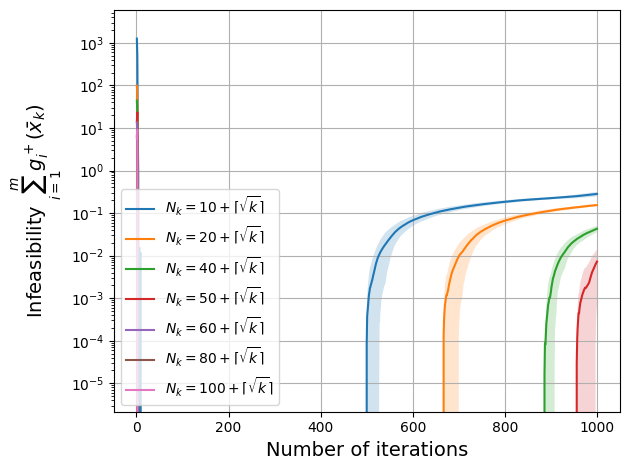

In [63]:
iters = np.arange(1, Tot_itr + 1)

# ------------------------------------------------------------
# Infeasibility Plot
# ------------------------------------------------------------
figure(3)
for Nk in Nk_values:
    res = dows_results[Nk]
    plt.plot(iters, res["mean_infeas"], label=f"$N_k={Nk} + \\lceil \\sqrt{{k}} \\rceil$")
    plt.fill_between(
        iters,
        res["mean_infeas"] - res["std_infeas"],
        res["mean_infeas"] + res["std_infeas"],
        alpha=0.2
    )

plt.xlabel("Number of iterations", fontsize=14)
plt.ylabel(r"Infeasibility $\sum_{i=1}^m g_i^+(\bar x_k)$", fontsize=14)
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()